## Convolutions with LSTMs

In [1]:
import os
# Set TF's logging level to suppress 'INFO' messages (like the ones shown)
# '3' is ERROR, '2' is WARNING, '1' is INFO (default is often 0 or 1)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

### Utilities

In [18]:
def plot_series(x, y, format="-", start=0, end=None,
                title=None, xlabel=None, ylabel=None, legend=None ):
    """
    Visualizes time series data

    Args:
      x (array of int) - contains values for the x-axis
      y (array of int or tuple of arrays) - contains the values for the y-axis
      format (string) - line style when plotting the graph
      start (int) - first time step to plot
      end (int) - last time step to plot
      title (string) - title of the plot
      xlabel (string) - label for the x-axis
      ylabel (string) - label for the y-axis
      legend (list of strings) - legend for the plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))

    # Check if there are more than two series to plot
    if type(y) is tuple:

      # Loop over the y elements
      for y_curr in y:

        # Plot the x and current y values
        plt.plot(x[start:end], y_curr[start:end], format)

    else:
      # Plot the x and y values
      plt.plot(x[start:end], y[start:end], format)

    # Label the x-axis
    plt.xlabel(xlabel)

    # Label the y-axis
    plt.ylabel(ylabel)

    # Set the legend
    if legend:
      plt.legend(legend)

    # Set the title
    plt.title(title)

    # Overlay a grid on the graph
    plt.grid(True)

    # Draw the graph on screen
    plt.show()

def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series

def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish

    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

    return data_pattern

def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """

    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern

def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level

    return noise

### Generate the Synthetic Data

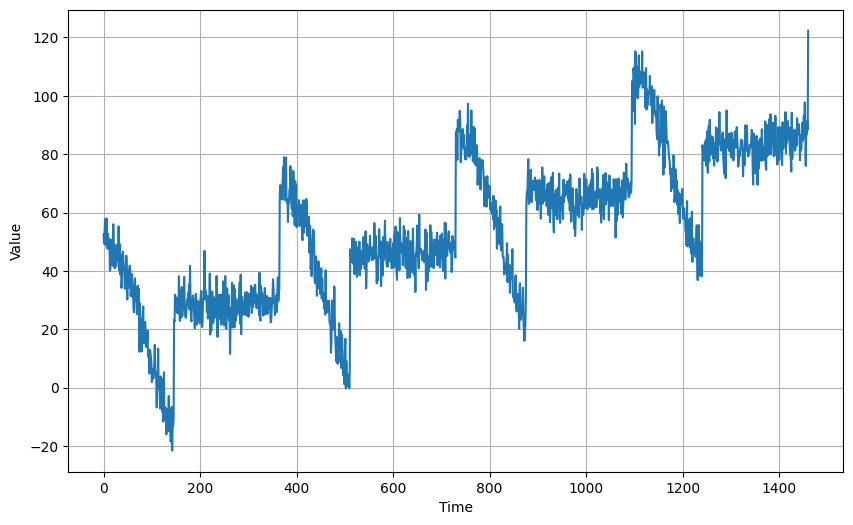

In [3]:
# Parameters
time = np.arange(4 * 365 + 1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

# Update with noise
series += noise(time, noise_level, seed=42)

# Plot the results
plot_series(time, series)

### Split dataset

In [4]:
# Define the split time
split_time = 1000

# Get the train set
time_train = time[:split_time]
x_train = series[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = series[split_time:]

### Prepare features and labels

In [5]:
# Parameters
window_size = 20
batch_size = 32
shuffle_buffer_size = 1000

In [6]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float/Numpy array) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """

    # Add an axis for the feature dimension
    series = tf.expand_dims(series, axis=-1)

    # Generate the tf.data.Dataset from the series
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Create a windowed dataset but only take those with the specified size (remove the last left over)
    dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)

    # Flatten the window by putting elements into single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels - Apply transformation to every single windowed dataset
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle
    dataset = dataset.shuffle(shuffle_buffer)

    # Create batches of windows
    dataset = dataset.batch(batch_size)
    dataset = dataset.cache().prefetch(1)
    return dataset

In [7]:
dataset = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

In [8]:
for window in dataset.take(1):
    print(f"Shape of feature: {window[0].shape}")
    print(f"Shape of label: {window[1].shape}")
    print(f"Data itself: {window}")

Shape of feature: (32, 20, 1)
Shape of label: (32, 1)
Data itself: (<tf.Tensor: shape=(32, 20, 1), dtype=float32, numpy=
array([[[ 34.231815  ],
        [ 40.183838  ],
        [ 41.78223   ],
        [ 40.778324  ],
        [ 31.413605  ],
        [ 33.544636  ],
        [ 36.221428  ],
        [ 38.910835  ],
        [ 31.098982  ],
        [ 32.022236  ],
        [ 26.868631  ],
        [ 25.863333  ],
        [ 35.345516  ],
        [ 37.49725   ],
        [ 29.783985  ],
        [ 34.584698  ],
        [ 30.793396  ],
        [ 25.17319   ],
        [ 29.614908  ],
        [ 34.90301   ]],

       [[ 43.210567  ],
        [ 37.96383   ],
        [ 38.81263   ],
        [ 47.153587  ],
        [ 48.175312  ],
        [ 42.31936   ],
        [ 49.998848  ],
        [ 38.46393   ],
        [ 46.40746   ],
        [ 40.649796  ],
        [ 43.413387  ],
        [ 46.87793   ],
        [ 42.307915  ],
        [ 44.656895  ],
        [ 51.5815    ],
        [ 43.636585  ],
        [ 50.

### Explanation of the features shape <br>


<br>
Detailed Breakdown

1. 32: The Batch Size
This means the tensor contains 32 complete time windows. When the model trains, it doesn't process one data point at a time; it processes a batch of 32 windows simultaneously. This is done for efficiency and smoother gradient estimation during training.

2. 20: The Window Size (Time Steps)
This is the core of the time series preparation. Each of the 32 samples is a sequence of 20 consecutive time steps (e.g., t−19,t−18,…,t−1). This sequence of 20 values is the historical context the model uses to learn to predict the next value.

3. 1: The Feature Dimension
This dimension indicates that the time series is univariate, meaning it only contains values for a single variable (e.g., only temperature, only stock price, only sales count). If you were tracking multiple related variables (e.g., temperature, humidity, and pressure), this dimension would be 3 (multivariate time series), and the shape would be (32, 20, 3).

### Build the model

<br>


Here is the model architecture you will be using. It is very similar to the last RNN you built but with the [Conv1D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D) layer at the input. One important [argument](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D#args) here is the `padding`. For time series data, it is good practice to not let computations for a particular time step to be affected by values into the future. Here is one way of looking at it:

* Let's say you have a small time series window with these values: `[1, 2, 3, 4, 5]`. This means the value `1` is at `t=0`, `2` is at `t=1`, etc.
* If you have a 1D kernel of size `3`, then the first convolution will be for the values at `[1, 2, 3]` which are values for `t=0` to `t=2`.
* When you pass this to the first timestep of the `LSTM` after the convolution, it means that the value at `t=0` of the LSTM depends on `t=1` and `t=2` which are values into the future.
* For time series data, you want computations to only rely on current and previous time steps.
* One way to do that is to pad the array depending on the kernel size and stride. For a kernel size of 3 and stride of 1, the window can be padded as such: `[0, 0, 1, 2, 3, 4, 5]`. `1` is still at `t=0` and two zeroes are prepended to simulate values in the past.
* This way, the first stride will be at `[0, 0, 1]` and this does not contain any future values when it is passed on to subsequent layers.

The `Conv1D` layer does this kind of padding by setting `padding=causal` and you'll see that below.

In [9]:
input_layer = tf.keras.Input(shape=(window_size, 1))
x = tf.keras.layers.Conv1D(filters=64, kernel_size=3,
                          strides=1, padding='causal',
                          activation='relu')(input_layer)
x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
x = tf.keras.layers.LSTM(64)(x)
x = tf.keras.layers.Dense(1)(x)
output_layer = tf.keras.layers.Lambda(lambda x: x*400)(x)

model = tf.keras.Model(input_layer, output_layer)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

### Tune the learning rate

In [11]:
# Get initial weights
init_weights = model.get_weights()

In [12]:
# Set the learning rate scheduler
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20))

optimizer = tf.keras.optimizers.SGD(momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer)
history = model.fit(dataset, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 29.2596 - learning_rate: 1.0000e-08
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.3915 - learning_rate: 1.1220e-08
Epoch 3/100
 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25.8298

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.8622 - learning_rate: 1.2589e-08
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.1540 - learning_rate: 1.4125e-08
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.3273 - learning_rate: 1.5849e-08
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.3553 - learning_rate: 1.7783e-08
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.2339 - learning_rate: 1.9953e-08
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.9875 - learning_rate: 2.2387e-08
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.7363 - learning_rate: 2.5119e-08
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.6426 - learning_rate: 2.8184e-08
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8314 - learning_rate: 3.1623e-08
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.4955 - learning_rate: 3.5481e-08
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7

(np.float64(1e-08), np.float64(0.001), np.float64(0.0), np.float64(50.0))

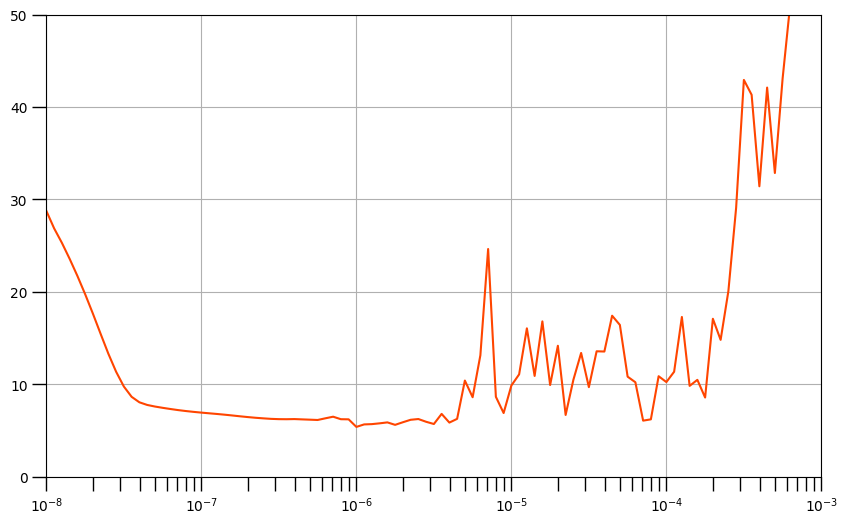

In [13]:
lrs = 1e-8 * (10 ** (np.arange(100) / 20))
# Set the figure size
plt.figure(figsize=(10, 6))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"], color="orangered")

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-8, 1e-3, 0, 50])

### Train the actual model

In [14]:
tf.keras.backend.clear_session()

model.set_weights(init_weights)

In [15]:
# Set the learning rate
learning_rate = 1e-7

# Set the optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

# Set the training parameters
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

In [16]:
# Train the model
history = model.fit(dataset,epochs=500)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 27.4931 - mae: 27.9877
Epoch 2/500
10/31 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 18.4817 - mae: 18.9755

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 16.7353 - mae: 17.2287
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8099 - mae: 9.2951
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3210 - mae: 7.7987
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9700 - mae: 7.4498
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7850 - mae: 7.2621
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6342 - mae: 7.1151
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5234 - mae: 7.0058
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4391 - mae: 6.9215
Epoch 10/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3675 - mae: 6.8480
Epoch 11/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3024 - mae: 6.7808
Epoch 12/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2420 - mae: 6.7201
Epoch 13/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1858 - mae: 6.6634
Epoch 14/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

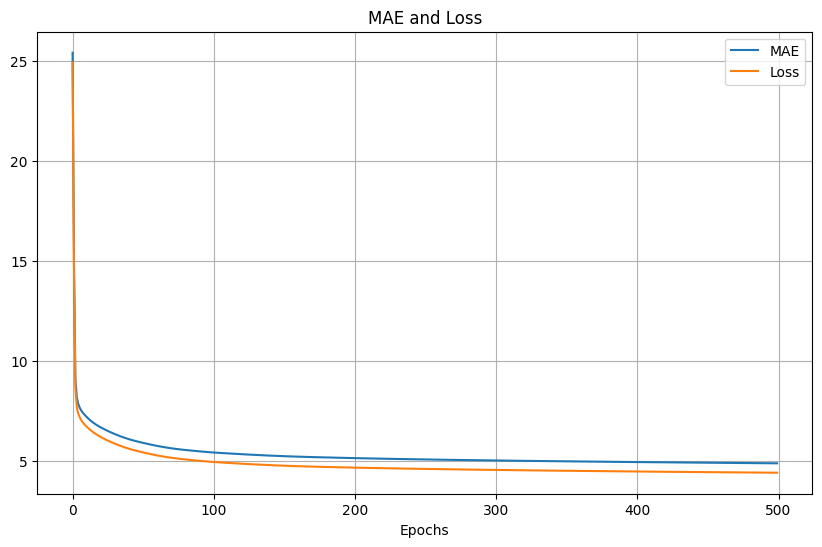

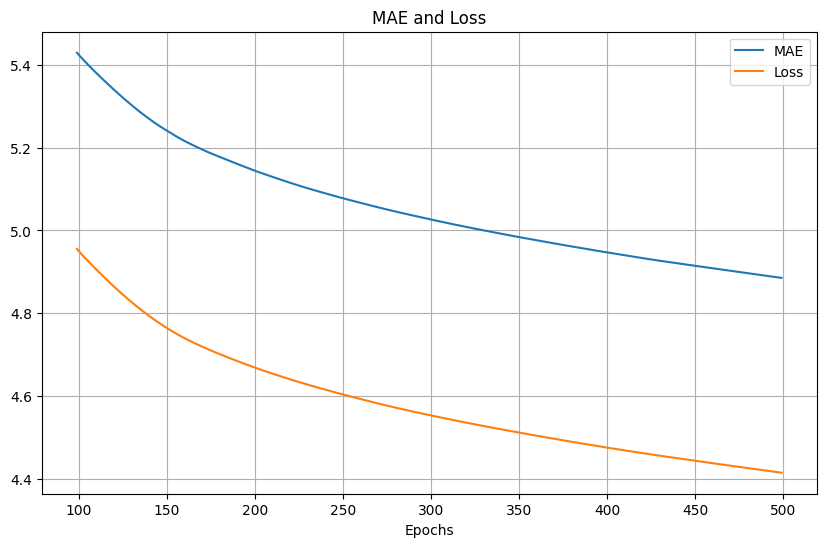

In [19]:
# Get mae and loss from history log
mae=history.history['mae']
loss=history.history['loss']

# Get number of epochs
epochs=range(len(loss))

# Plot mae and loss
plot_series(
    x=epochs,
    y=(mae, loss),
    title='MAE and Loss',
    xlabel='Epochs',
    legend=['MAE', 'Loss']
    )

# Only plot the last 80% of the epochs
zoom_split = int(epochs[-1] * 0.2)
epochs_zoom = epochs[zoom_split:]
mae_zoom = mae[zoom_split:]
loss_zoom = loss[zoom_split:]

# Plot zoomed mae and loss
plot_series(
    x=epochs_zoom,
    y=(mae_zoom, loss_zoom),
    title='MAE and Loss',
    xlabel='Epochs',
    legend=['MAE', 'Loss']
    )

## Model Prediction

Generate model predictions for the validation set time range

In [20]:
def model_forecast(model, series, window_size, batch_size):
    """Uses an input model to generate predictions on data windows

    Args:
      model (TF Keras Model) - model that accepts data windows
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the window
      batch_size (int) - the batch size

    Returns:
      forecast (numpy array) - array containing predictions
    """

    # Add an axis for the feature dimension of RNN layers
    series = tf.expand_dims(series, axis=-1)

    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda w: w.batch(window_size))

    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)

    # Get predictions on the entire dataset
    forecast = model.predict(dataset, verbose=0)

    return forecast

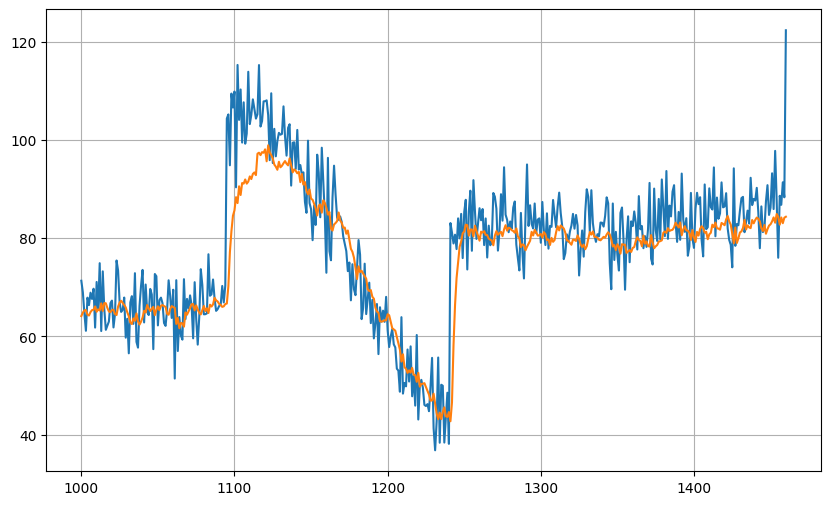

In [21]:
# Reduce the original series
forecast_series = series[split_time-window_size:-1]

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axes
results = forecast.squeeze()

# Plot the results
plot_series(time_valid, (x_valid, results))

In [22]:
## Compute the MAE and MSE
print(tf.keras.metrics.mse(x_valid, results).numpy())
print(tf.keras.metrics.mae(x_valid, results).numpy())

59.8045
5.551439
